In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from src.geometry import E320PrototypeGeometry, SENSOR_TO_LAYER

In [2]:
# Load data and compute TRK coordinates
DATA_PATH = "/Users/IvanTang/hep/data_Run502/hit_level.parquet"

geom = E320PrototypeGeometry(use_alignment=True)

df = pd.read_parquet(DATA_PATH)
df = df[df["det_type"] == "pixel"].copy()
df["layer_id"] = df["sensor_id"].map(SENSOR_TO_LAYER)

coords = df.apply(
    lambda r: geom.pixel_to_trk_mm(int(r["layer_id"]), float(r["hit_x"]), float(r["hit_y"])),
    axis=1,
)
df[["x_trk_mm", "y_trk_mm", "z_trk_mm"]] = pd.DataFrame(coords.tolist(), index=df.index)

print(f"Total pixel hits: {len(df)},  events: {df['event_id'].nunique()},  layers: {sorted(df['layer_id'].unique())}")
df.head()

Total pixel hits: 5360276,  events: 1770,  layers: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


,event_id,entry,det_type,stave_id,sensor_id,hit_x,hit_y,size_x,size_y,size,mean_x,mean_y,stddev_x,stddev_y,layer_id,x_trk_mm,y_trk_mm,z_trk_mm
0,0,0,pixel,0,6,1023.0,372.0,1,1,1,-1.0,-1.0,-1.0,-1.0,3,14.903102,3.059046,60.0
1,0,0,pixel,0,6,1022.5,193.0,2,1,2,-1.0,-1.0,-1.0,-1.0,3,14.881352,-1.773927,60.0
2,0,0,pixel,0,6,1019.0,173.0,1,1,1,-1.0,-1.0,-1.0,-1.0,3,14.779042,-2.313774,60.0
3,0,0,pixel,0,6,1015.5,179.0,2,1,2,-1.0,-1.0,-1.0,-1.0,3,14.677785,-2.151622,60.0
4,0,0,pixel,0,6,1013.5,181.5,2,2,4,-1.0,-1.0,-1.0,-1.0,3,14.619887,-2.084035,60.0


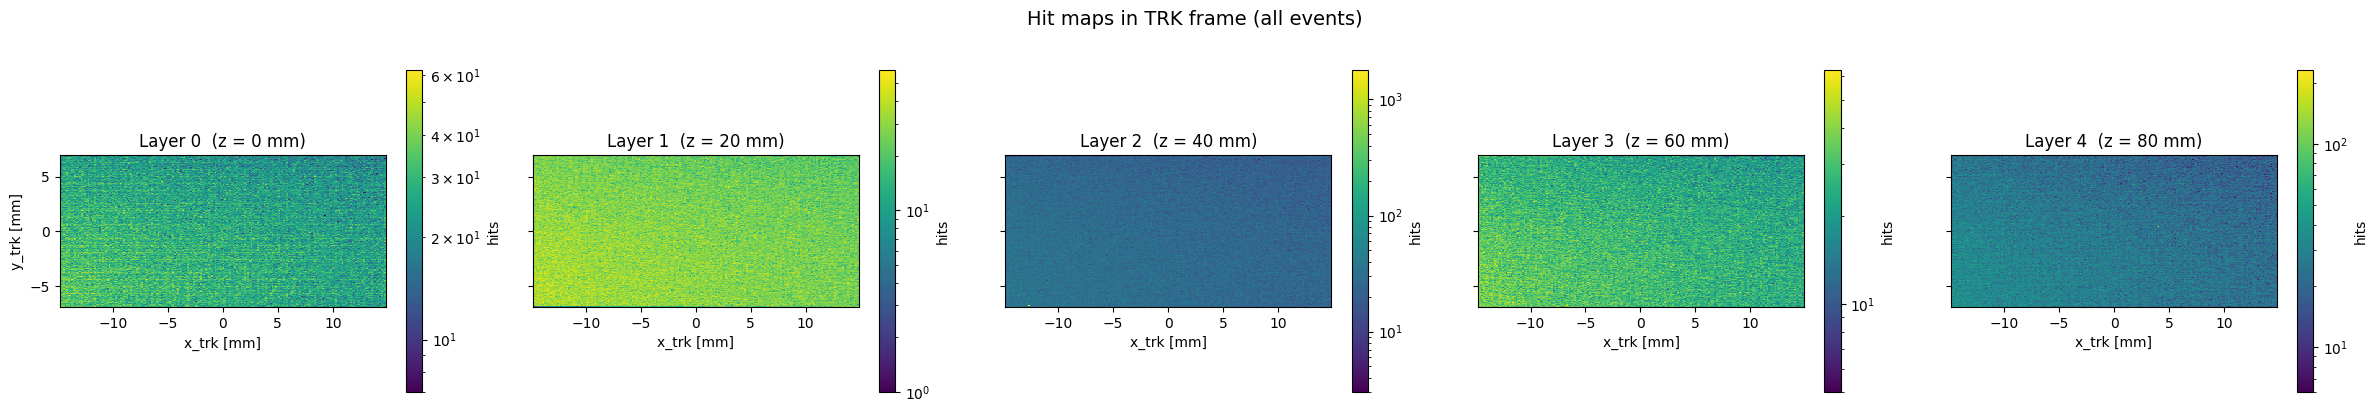

In [3]:
# 1. Per-layer x_trk vs y_trk hitmaps
fig, axes = plt.subplots(1, 5, figsize=(24, 4), sharey=True)

for i, ax in enumerate(axes):
    layer_df = df[df["layer_id"] == i]
    h = ax.hist2d(
        layer_df["x_trk_mm"], layer_df["y_trk_mm"],
        bins=200,
        norm=mcolors.LogNorm(),
        cmap="viridis",
    )
    ax.set_title(f"Layer {i}  (z = {geom.layers[i].z_trk_mm:.0f} mm)")
    ax.set_xlabel("x_trk [mm]")
    if i == 0:
        ax.set_ylabel("y_trk [mm]")
    ax.set_aspect("equal")
    fig.colorbar(h[3], ax=ax, label="hits")

fig.suptitle("Hit maps in TRK frame (all events)", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

Event 0: 3021 hits across 5 layers


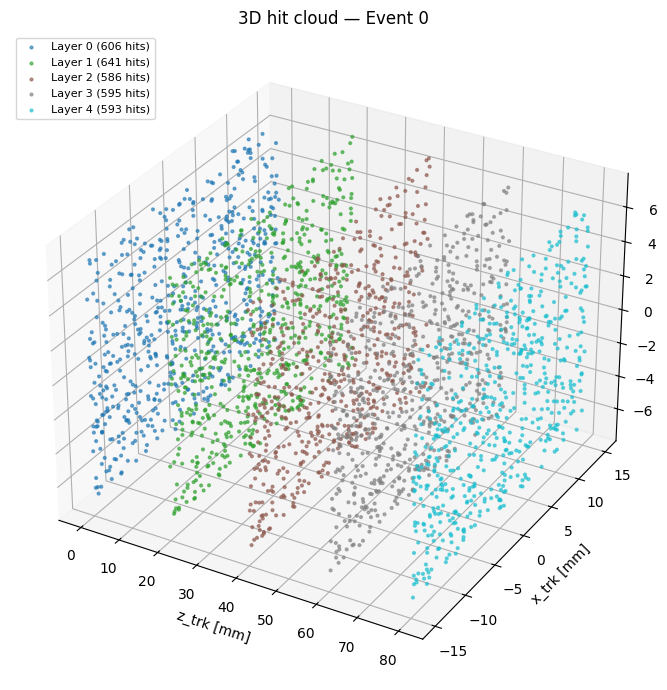

In [3]:
# 2. 3D point cloud of a single event
# Pick an event with a decent number of hits
hit_counts = df.groupby("event_id").size()
example_event = hit_counts[(hit_counts > 50) & (hit_counts < 5000)].index[0]

evt = df[df["event_id"] == example_event]
print(f"Event {example_event}: {len(evt)} hits across {evt['layer_id'].nunique()} layers")

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

colors = plt.cm.tab10(np.linspace(0, 1, 5))
for lid in range(5):
    sub = evt[evt["layer_id"] == lid]
    if len(sub) == 0:
        continue
    ax.scatter(
        sub["z_trk_mm"], sub["x_trk_mm"], sub["y_trk_mm"],
        s=4, alpha=0.6, color=colors[lid],
        label=f"Layer {lid} ({len(sub)} hits)",
    )

ax.set_xlabel("z_trk [mm]")
ax.set_ylabel("x_trk [mm]")
ax.set_zlabel("y_trk [mm]")
ax.set_title(f"3D hit cloud — Event {example_event}")
ax.legend(loc="upper left", fontsize=8)
fig.tight_layout()
plt.show()

## Build Edges

In [4]:
import numpy as np
import pandas as pd


def build_adjacent_edges_for_event(
    evt_df: pd.DataFrame,
    x_window_mm: float = 3.0,
    y_window_mm: float = 3.0,
) -> pd.DataFrame:
    """
    Build candidate edges only between adjacent layers:
    0->1, 1->2, 2->3, 3->4

    Returns a DataFrame with one row per candidate edge.
    """
    evt_df = evt_df.reset_index(drop=False).rename(columns={"index": "node_id"})
    out = []

    for layer in range(4):
        a = evt_df[evt_df["layer_id"] == layer].copy()
        b = evt_df[evt_df["layer_id"] == layer + 1].copy()

        if len(a) == 0 or len(b) == 0:
            continue

        ax = a["x_trk_mm"].to_numpy()
        ay = a["y_trk_mm"].to_numpy()
        az = a["z_trk_mm"].to_numpy()
        aid = a["node_id"].to_numpy()

        bx = b["x_trk_mm"].to_numpy()
        by = b["y_trk_mm"].to_numpy()
        bz = b["z_trk_mm"].to_numpy()
        bid = b["node_id"].to_numpy()

        # pairwise differences: shape (len(a), len(b))
        dx = bx[None, :] - ax[:, None]
        dy = by[None, :] - ay[:, None]
        dz = bz[None, :] - az[:, None]

        mask = (np.abs(dx) < x_window_mm) & (np.abs(dy) < y_window_mm)

        ia, ib = np.where(mask)
        if len(ia) == 0:
            continue

        edge_df = pd.DataFrame({
            "src_node": aid[ia],
            "dst_node": bid[ib],
            "src_layer": layer,
            "dst_layer": layer + 1,
            "dx_mm": dx[ia, ib],
            "dy_mm": dy[ia, ib],
            "dz_mm": dz[ia, ib],
        })
        edge_df["dr_mm"] = np.sqrt(edge_df["dx_mm"]**2 + edge_df["dy_mm"]**2)
        edge_df["slope_x"] = edge_df["dx_mm"] / edge_df["dz_mm"]
        edge_df["slope_y"] = edge_df["dy_mm"] / edge_df["dz_mm"]

        out.append(edge_df)

    if not out:
        return pd.DataFrame(columns=[
            "src_node", "dst_node", "src_layer", "dst_layer",
            "dx_mm", "dy_mm", "dz_mm", "dr_mm", "slope_x", "slope_y"
        ])

    return pd.concat(out, ignore_index=True)

def build_edges_all_events(df_pixel: pd.DataFrame,
                           x_window_mm: float = 3.0,
                           y_window_mm: float = 3.0) -> pd.DataFrame:
    all_edges = []

    for event_id, evt in df_pixel.groupby("event_id", sort=True):
        edges = build_adjacent_edges_for_event(
            evt,
            x_window_mm=x_window_mm,
            y_window_mm=y_window_mm,
        )
        edges["event_id"] = event_id
        all_edges.append(edges)

    if not all_edges:
        return pd.DataFrame()

    return pd.concat(all_edges, ignore_index=True)

In [5]:
df_pixel = df[df['det_type'] == 'pixel']
edges = build_edges_all_events(df_pixel, x_window_mm=3.0, y_window_mm=3.0)

print(edges.head())

print(edges.groupby(["src_layer", "dst_layer"]).size())

print(edges.groupby("event_id").size().describe())

   src_node  dst_node  src_layer  dst_layer     dx_mm     dy_mm  dz_mm  \
0      2415       596          0          1 -0.232285 -2.736395   20.0   
1      2415       606          0          1 -1.062902  0.347605   20.0   
2      2415       607          0          1 -1.183136  0.680822   20.0   
3      2415       608          0          1 -1.401899 -0.020785   20.0   
4      2415       609          0          1 -1.473305  0.586844   20.0   

      dr_mm   slope_x   slope_y  event_id  
0  2.746236 -0.011614 -0.136820         0  
1  1.118298 -0.053145  0.017380         0  
2  1.365038 -0.059157  0.034041         0  
3  1.402053 -0.070095 -0.001039         0  
4  1.585880 -0.073665  0.029342         0  
src_layer  dst_layer
0          1            50685848
1          2            51118969
2          3            50418502
3          4            48146258
dtype: int64
count      1770.000000
mean     113203.150847
std        9552.785610
min           4.000000
25%      106885.500000
50%      1

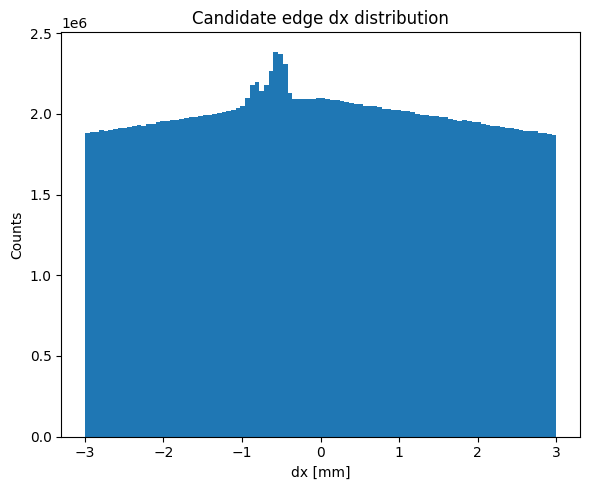

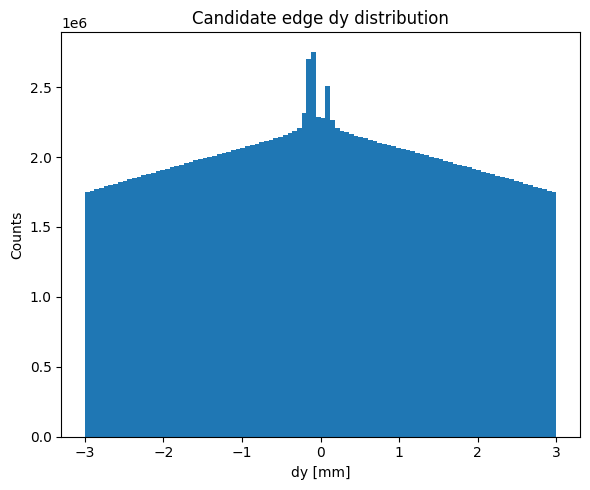

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.hist(edges["dx_mm"], bins=100)
plt.xlabel("dx [mm]")
plt.ylabel("Counts")
plt.title("Candidate edge dx distribution")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.hist(edges["dy_mm"], bins=100)
plt.xlabel("dy [mm]")
plt.ylabel("Counts")
plt.title("Candidate edge dy distribution")
plt.tight_layout()
plt.show()

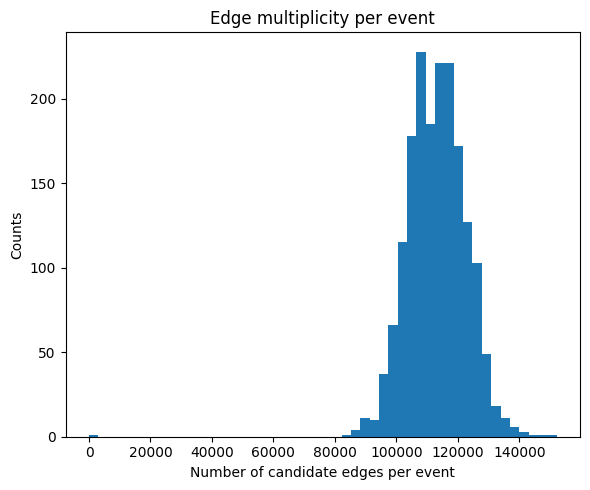

In [12]:
edge_counts = edges.groupby("event_id").size()

plt.figure(figsize=(6, 5))
plt.hist(edge_counts, bins=50)
plt.xlabel("Number of candidate edges per event")
plt.ylabel("Counts")
plt.title("Edge multiplicity per event")
plt.tight_layout()
plt.show()

## Graph Compression: Slope Window + KNN

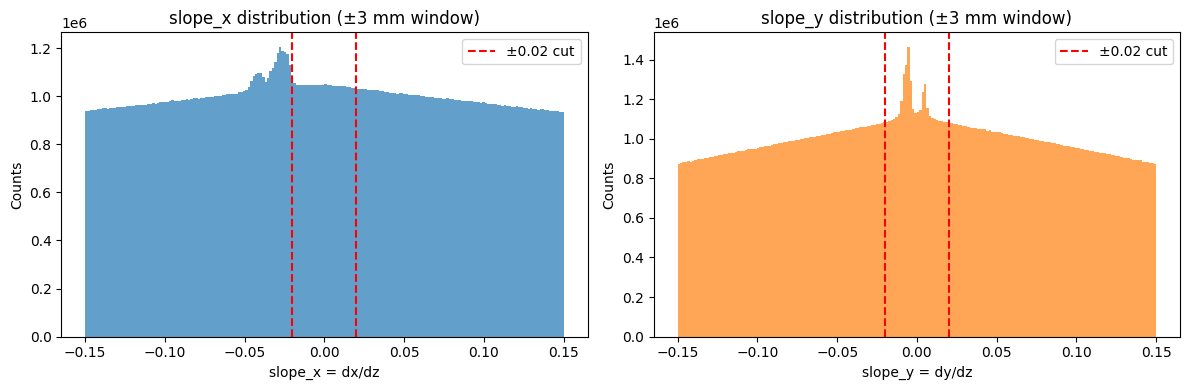

In [20]:
# 3. Slope distributions from current wide-window edges
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(edges["slope_x"], bins=200, histtype="stepfilled", alpha=0.7)
axes[0].set_xlabel("slope_x = dx/dz")
axes[0].set_ylabel("Counts")
axes[0].set_title("slope_x distribution (±3 mm window)")
axes[0].axvline(0.02, color="r", ls="--", label="±0.02 cut")
axes[0].axvline(-0.02, color="r", ls="--")
axes[0].legend()

axes[1].hist(edges["slope_y"], bins=200, histtype="stepfilled", alpha=0.7, color="C1")
axes[1].set_xlabel("slope_y = dy/dz")
axes[1].set_ylabel("Counts")
axes[1].set_title("slope_y distribution (±3 mm window)")
axes[1].axvline(0.02, color="r", ls="--", label="±0.02 cut")
axes[1].axvline(-0.02, color="r", ls="--")
axes[1].legend()

fig.tight_layout()
plt.show()

In [6]:
# Optimized edge builder: slope window + KNN pruning
def build_edges_slope_knn(
    evt_df: pd.DataFrame,
    slope_x_max: float = 0.02,
    slope_y_max: float = 0.02,
    k_max: int = 10,
) -> pd.DataFrame:
    """
    Build edges between adjacent layers with:
      1) slope window:  |dx/dz| < slope_x_max,  |dy/dz| < slope_y_max
      2) KNN pruning:   per source node, keep only the k_max nearest (by dr) edges
    """
    evt_df = evt_df.reset_index(drop=False).rename(columns={"index": "node_id"})
    out = []

    for layer in range(4):
        a = evt_df[evt_df["layer_id"] == layer]
        b = evt_df[evt_df["layer_id"] == layer + 1]
        if len(a) == 0 or len(b) == 0:
            continue

        ax = a["x_trk_mm"].to_numpy()
        ay = a["y_trk_mm"].to_numpy()
        az = a["z_trk_mm"].to_numpy()
        aid = a["node_id"].to_numpy()

        bx = b["x_trk_mm"].to_numpy()
        by = b["y_trk_mm"].to_numpy()
        bz = b["z_trk_mm"].to_numpy()
        bid = b["node_id"].to_numpy()

        dx = bx[None, :] - ax[:, None]
        dy = by[None, :] - ay[:, None]
        dz = bz[None, :] - az[:, None]

        slope_x = dx / dz
        slope_y = dy / dz

        # Slope window cut
        mask = (np.abs(slope_x) < slope_x_max) & (np.abs(slope_y) < slope_y_max)
        ia, ib = np.where(mask)
        if len(ia) == 0:
            continue

        dr = np.sqrt(dx[ia, ib]**2 + dy[ia, ib]**2)

        edge_df = pd.DataFrame({
            "src_node": aid[ia],
            "dst_node": bid[ib],
            "src_layer": layer,
            "dst_layer": layer + 1,
            "dx_mm": dx[ia, ib],
            "dy_mm": dy[ia, ib],
            "dz_mm": dz[ia, ib],
            "dr_mm": dr,
            "slope_x": slope_x[ia, ib],
            "slope_y": slope_y[ia, ib],
        })

        # KNN: per source node, keep only k_max closest edges
        if k_max is not None and k_max > 0:
            edge_df = (
                edge_df
                .sort_values("dr_mm")
                .groupby("src_node", sort=False)
                .head(k_max)
                .reset_index(drop=True)
            )

        out.append(edge_df)

    if not out:
        return pd.DataFrame(columns=[
            "src_node", "dst_node", "src_layer", "dst_layer",
            "dx_mm", "dy_mm", "dz_mm", "dr_mm", "slope_x", "slope_y"
        ])
    return pd.concat(out, ignore_index=True)


def build_compressed_edges_all(
    df_pixel: pd.DataFrame,
    slope_x_max: float = 0.02,
    slope_y_max: float = 0.02,
    k_max: int = 10,
) -> pd.DataFrame:
    all_edges = []
    for event_id, evt in df_pixel.groupby("event_id", sort=True):
        e = build_edges_slope_knn(evt, slope_x_max, slope_y_max, k_max)
        e["event_id"] = event_id
        all_edges.append(e)
    if not all_edges:
        return pd.DataFrame()
    return pd.concat(all_edges, ignore_index=True)

In [22]:
# Scan different slope windows to find optimal compression
scan_results = []
for smax in [0.15, 0.08, 0.04, 0.02, 0.01]:
    # Build for a few events to estimate quickly
    sample_events = df["event_id"].unique()[:50]
    df_sample = df[df["event_id"].isin(sample_events)]
    
    e = build_compressed_edges_all(df_sample, slope_x_max=smax, slope_y_max=smax, k_max=None)
    stats = e.groupby("event_id").size()
    scan_results.append({
        "slope_max": smax,
        "dx_equiv_mm": smax * 20,
        "mean_edges": stats.mean(),
        "median_edges": stats.median(),
        "max_edges": stats.max(),
    })
    print(f"slope_max={smax:.3f}  (|dx|<{smax*20:.1f} mm)  →  mean={stats.mean():.0f}  median={stats.median():.0f}  max={stats.max()}")

scan_df = pd.DataFrame(scan_results)
scan_df

slope_max=0.150  (|dx|<3.0 mm)  →  mean=111606  median=111576  max=124539
slope_max=0.080  (|dx|<1.6 mm)  →  mean=35069  median=35113  max=39401
slope_max=0.040  (|dx|<0.8 mm)  →  mean=9713  median=9740  max=11036
slope_max=0.020  (|dx|<0.4 mm)  →  mean=2315  median=2330  max=2704
slope_max=0.010  (|dx|<0.2 mm)  →  mean=575  median=570  max=673


,slope_max,dx_equiv_mm,mean_edges,median_edges,max_edges
0,0.15,3.0,111605.54,111576.5,124539
1,0.08,1.6,35068.94,35113.0,39401
2,0.04,0.8,9713.38,9740.5,11036
3,0.02,0.4,2315.46,2330.5,2704
4,0.01,0.2,575.26,569.5,673


In [7]:
# Build compressed edges with slope=0.02 + KNN k=10
edges_compressed = build_compressed_edges_all(df, slope_x_max=0.02, slope_y_max=0.02, k_max=10)

stats_old = edges.groupby("event_id").size()
stats_new = edges_compressed.groupby("event_id").size()

print("=== Before (±3 mm window) ===")
print(stats_old.describe())
print(f"\n=== After (slope<0.02, KNN k=10) ===")
print(stats_new.describe())
print(f"\nCompression ratio: {stats_old.mean() / stats_new.mean():.1f}x")

=== Before (±3 mm window) ===
count      1770.000000
mean     113203.150847
std        9552.785610
min           4.000000
25%      106885.500000
50%      113261.500000
75%      119450.750000
max      152151.000000
dtype: float64

=== After (slope<0.02, KNN k=10) ===
count    1770.000000
mean     2346.237853
std       204.228212
min         1.000000
25%      2210.250000
50%      2341.500000
75%      2482.000000
max      3188.000000
dtype: float64

Compression ratio: 48.2x


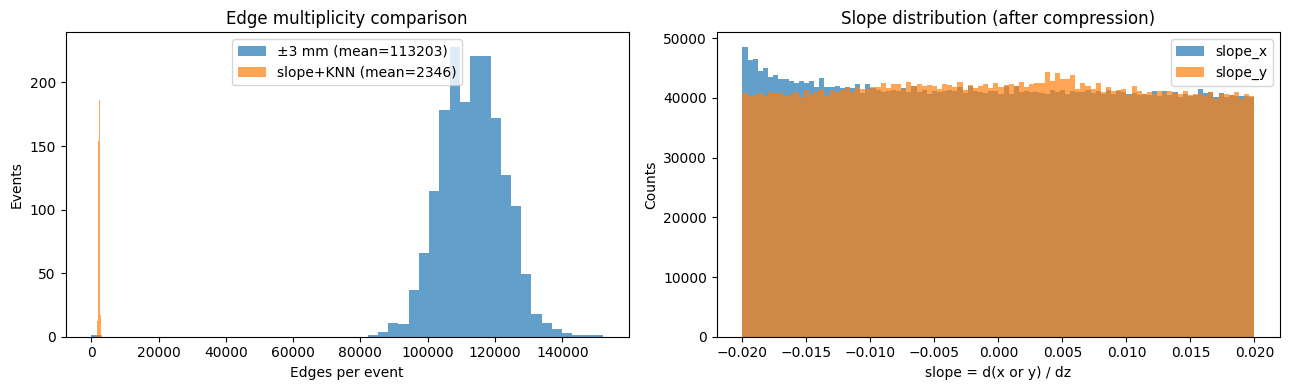

In [24]:
# Compare edge multiplicity: before vs after
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(stats_old, bins=50, alpha=0.7, label=f"±3 mm (mean={stats_old.mean():.0f})")
axes[0].hist(stats_new, bins=50, alpha=0.7, label=f"slope+KNN (mean={stats_new.mean():.0f})")
axes[0].set_xlabel("Edges per event")
axes[0].set_ylabel("Events")
axes[0].set_title("Edge multiplicity comparison")
axes[0].legend()

# Slope distributions after compression
axes[1].hist(edges_compressed["slope_x"], bins=100, alpha=0.7, label="slope_x")
axes[1].hist(edges_compressed["slope_y"], bins=100, alpha=0.7, label="slope_y")
axes[1].set_xlabel("slope = d(x or y) / dz")
axes[1].set_ylabel("Counts")
axes[1].set_title("Slope distribution (after compression)")
axes[1].legend()

fig.tight_layout()
plt.show()

In [25]:
# Per layer-pair statistics after compression
print("Edges per layer pair (compressed):")
print(edges_compressed.groupby(["src_layer", "dst_layer"]).size())
print()

# Per-node degree distribution
src_degree = edges_compressed.groupby(["event_id", "src_node"]).size()
print(f"Out-degree stats (per source node):")
print(src_degree.describe())

Edges per layer pair (compressed):
src_layer  dst_layer
0          1            1069663
1          2            1064103
2          3            1036341
3          4             982734
dtype: int64

Out-degree stats (per source node):
count    2.660582e+06
mean     1.560877e+00
std      7.996888e-01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      1.000000e+01
dtype: float64


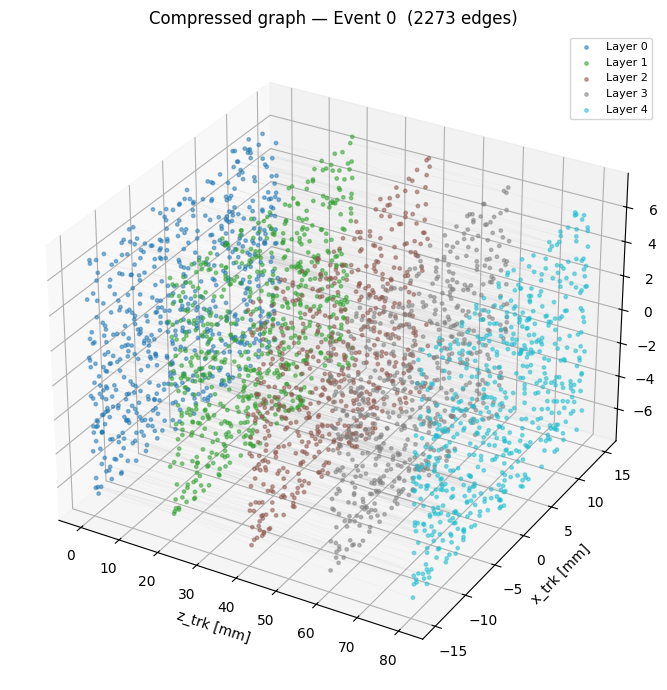

In [26]:
# Visualize compressed graph for a single event
evt_edges = edges_compressed[edges_compressed["event_id"] == example_event]
evt_nodes = df.loc[df["event_id"] == example_event]

fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection="3d")

# Draw hits
colors_layer = plt.cm.tab10(np.linspace(0, 1, 5))
for lid in range(5):
    sub = evt_nodes[evt_nodes["layer_id"] == lid]
    ax.scatter(sub["z_trk_mm"], sub["x_trk_mm"], sub["y_trk_mm"],
               s=6, alpha=0.5, color=colors_layer[lid], label=f"Layer {lid}")

# Draw edges as lines
node_lookup = evt_nodes[["x_trk_mm", "y_trk_mm", "z_trk_mm"]]
for _, e in evt_edges.iterrows():
    src = node_lookup.loc[e["src_node"]]
    dst = node_lookup.loc[e["dst_node"]]
    ax.plot(
        [src["z_trk_mm"], dst["z_trk_mm"]],
        [src["x_trk_mm"], dst["x_trk_mm"]],
        [src["y_trk_mm"], dst["y_trk_mm"]],
        color="gray", alpha=0.08, lw=0.3,
    )

ax.set_xlabel("z_trk [mm]")
ax.set_ylabel("x_trk [mm]")
ax.set_zlabel("y_trk [mm]")
ax.set_title(f"Compressed graph — Event {example_event}  ({len(evt_edges)} edges)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## Triplet Baseline: Slope Consistency Across 3 Layers

In [8]:
def build_triplets_for_event(
    evt_edges: pd.DataFrame,
    dslope_x_max: float = 0.005,
    dslope_y_max: float = 0.005,
) -> pd.DataFrame:
    """
    Build triplets from consecutive edge pairs sharing a middle node.
    Edge (A->B on layer i->i+1) + Edge (B->C on layer i+1->i+2)
    Filter by slope consistency: |slope_01 - slope_12| < epsilon
    """
    triplets = []

    for mid_layer in range(1, 4):  # middle node on layers 1, 2, 3
        # Edges ending at mid_layer (src_layer = mid_layer-1)
        e_in = evt_edges[evt_edges["dst_layer"] == mid_layer].copy()
        # Edges starting from mid_layer (src_layer = mid_layer)
        e_out = evt_edges[evt_edges["src_layer"] == mid_layer].copy()

        if len(e_in) == 0 or len(e_out) == 0:
            continue

        # Join on shared middle node: e_in.dst_node == e_out.src_node
        merged = e_in.merge(
            e_out,
            left_on="dst_node",
            right_on="src_node",
            suffixes=("_01", "_12"),
        )

        if len(merged) == 0:
            continue

        # Slope consistency
        merged["dslope_x"] = merged["slope_x_12"] - merged["slope_x_01"]
        merged["dslope_y"] = merged["slope_y_12"] - merged["slope_y_01"]

        mask = (
            (np.abs(merged["dslope_x"]) < dslope_x_max) &
            (np.abs(merged["dslope_y"]) < dslope_y_max)
        )
        passed = merged[mask].copy()

        if len(passed) == 0:
            continue

        triplets.append(pd.DataFrame({
            "node_a": passed["src_node_01"],
            "node_b": passed["dst_node_01"],  # = src_node_12
            "node_c": passed["dst_node_12"],
            "layer_start": mid_layer - 1,
            "slope_x_01": passed["slope_x_01"],
            "slope_y_01": passed["slope_y_01"],
            "slope_x_12": passed["slope_x_12"],
            "slope_y_12": passed["slope_y_12"],
            "dslope_x": passed["dslope_x"],
            "dslope_y": passed["dslope_y"],
        }))

    if not triplets:
        return pd.DataFrame(columns=[
            "node_a", "node_b", "node_c", "layer_start",
            "slope_x_01", "slope_y_01", "slope_x_12", "slope_y_12",
            "dslope_x", "dslope_y",
        ])
    return pd.concat(triplets, ignore_index=True)


def build_triplets_all_events(
    edges_df: pd.DataFrame,
    dslope_x_max: float = 0.005,
    dslope_y_max: float = 0.005,
) -> pd.DataFrame:
    all_triplets = []
    for event_id, evt_edges in edges_df.groupby("event_id", sort=True):
        t = build_triplets_for_event(evt_edges, dslope_x_max, dslope_y_max)
        t["event_id"] = event_id
        all_triplets.append(t)
    if not all_triplets:
        return pd.DataFrame()
    return pd.concat(all_triplets, ignore_index=True)

print("Triplet builder defined.")

Triplet builder defined.


In [28]:
# Scan dslope thresholds on a sample
sample_events = df["event_id"].unique()[:50]
edges_sample = edges_compressed[edges_compressed["event_id"].isin(sample_events)]

scan_triplet = []
for ds in [0.05, 0.02, 0.01, 0.005, 0.002, 0.001]:
    t = build_triplets_all_events(edges_sample, dslope_x_max=ds, dslope_y_max=ds)
    stats = t.groupby("event_id").size()
    scan_triplet.append({
        "dslope_max": ds,
        "mean_triplets": stats.mean(),
        "median_triplets": stats.median(),
        "max_triplets": stats.max(),
    })
    print(f"dslope_max={ds:.4f}  →  mean={stats.mean():.1f}  median={stats.median():.0f}  max={stats.max()}")

scan_triplet_df = pd.DataFrame(scan_triplet)
scan_triplet_df

dslope_max=0.0500  →  mean=1726.3  median=1716  max=2184
dslope_max=0.0200  →  mean=974.6  median=958  max=1251
dslope_max=0.0100  →  mean=330.5  median=329  max=438
dslope_max=0.0050  →  mean=97.2  median=96  max=136
dslope_max=0.0020  →  mean=16.7  median=16  max=31
dslope_max=0.0010  →  mean=4.6  median=4  max=13


,dslope_max,mean_triplets,median_triplets,max_triplets
0,0.050,1726.26,1716.5,2184
1,0.020,974.62,958.5,1251
2,0.010,330.52,329.0,438
3,0.005,97.24,95.5,136
4,0.002,16.68,16.0,31
5,0.001,4.64,4.0,13


In [9]:
# Build triplets for all events with chosen threshold
DSLOPE_MAX = 0.005
triplets = build_triplets_all_events(edges_compressed, dslope_x_max=DSLOPE_MAX, dslope_y_max=DSLOPE_MAX)

triplet_stats = triplets.groupby("event_id").size()
print(f"dslope_max = {DSLOPE_MAX}")
print(f"Total triplets: {len(triplets)}")
print(f"\nTriplets per event:")
print(triplet_stats.describe())
print(f"\nTriplets per layer_start:")
print(triplets.groupby("layer_start").size())

dslope_max = 0.005
Total triplets: 171999

Triplets per event:
count    1769.000000
mean       97.229508
std        16.256304
min        49.000000
25%        86.000000
50%        96.000000
75%       108.000000
max       159.000000
dtype: float64

Triplets per layer_start:
layer_start
0    58625
1    60533
2    52841
dtype: int64


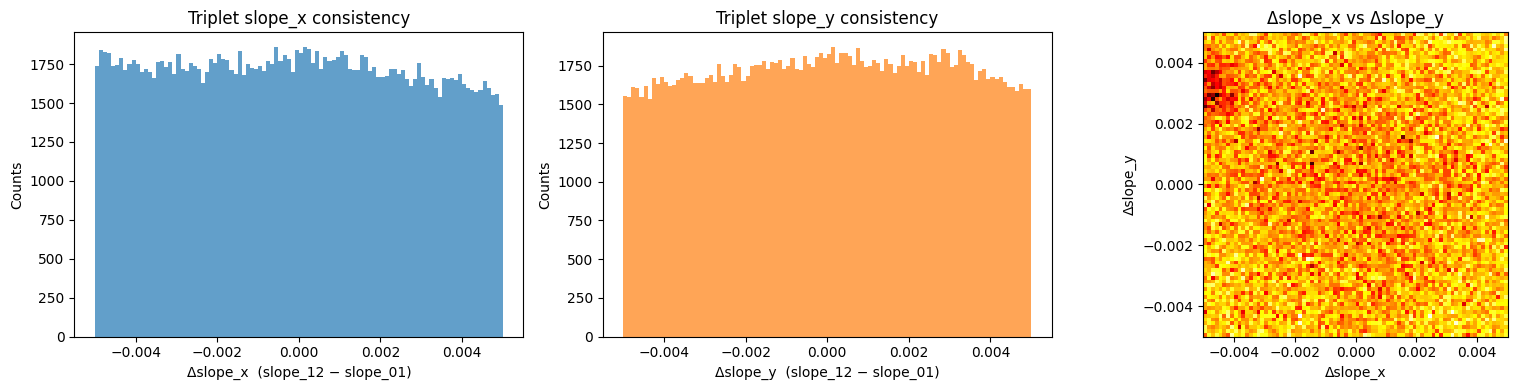

In [30]:
# Slope difference distributions for triplets
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(triplets["dslope_x"], bins=100, histtype="stepfilled", alpha=0.7)
axes[0].set_xlabel("Δslope_x  (slope_12 − slope_01)")
axes[0].set_ylabel("Counts")
axes[0].set_title("Triplet slope_x consistency")

axes[1].hist(triplets["dslope_y"], bins=100, histtype="stepfilled", alpha=0.7, color="C1")
axes[1].set_xlabel("Δslope_y  (slope_12 − slope_01)")
axes[1].set_ylabel("Counts")
axes[1].set_title("Triplet slope_y consistency")

# 2D: dslope_x vs dslope_y
axes[2].hist2d(triplets["dslope_x"], triplets["dslope_y"], bins=80, cmap="hot_r")
axes[2].set_xlabel("Δslope_x")
axes[2].set_ylabel("Δslope_y")
axes[2].set_title("Δslope_x vs Δslope_y")
axes[2].set_aspect("equal")

fig.tight_layout()
plt.show()

## Extend to 4-Layer and 5-Layer Chains

In [10]:
def build_chains_for_event(
    evt_edges: pd.DataFrame,
    dslope_x_max: float = 0.005,
    dslope_y_max: float = 0.005,
) -> dict:
    """
    Progressively extend triplets into 4-layer and 5-layer chains using
    slope consistency at every extension step.
    
    Returns dict with keys: 'triplets', 'quadruplets', 'quintuplets'
    Each is a list of tuples of node ids.
    """
    # Start from triplets (3-layer)
    triplets_3 = []
    for mid_layer in range(1, 4):
        e_in = evt_edges[evt_edges["dst_layer"] == mid_layer]
        e_out = evt_edges[evt_edges["src_layer"] == mid_layer]
        if len(e_in) == 0 or len(e_out) == 0:
            continue
        merged = e_in.merge(e_out, left_on="dst_node", right_on="src_node", suffixes=("_01", "_12"))
        if len(merged) == 0:
            continue
        mask = (
            (np.abs(merged["slope_x_12"] - merged["slope_x_01"]) < dslope_x_max) &
            (np.abs(merged["slope_y_12"] - merged["slope_y_01"]) < dslope_y_max)
        )
        for _, row in merged[mask].iterrows():
            triplets_3.append({
                "nodes": (row["src_node_01"], row["dst_node_01"], row["dst_node_12"]),
                "layers": (mid_layer - 1, mid_layer, mid_layer + 1),
                "last_slope_x": row["slope_x_12"],
                "last_slope_y": row["slope_y_12"],
            })

    # Extend to 4-layer chains
    # Build edge lookup: src_node -> list of (dst_node, slope_x, slope_y, dst_layer)
    edge_lookup = {}
    for _, e in evt_edges.iterrows():
        src = e["src_node"]
        if src not in edge_lookup:
            edge_lookup[src] = []
        edge_lookup[src].append((e["dst_node"], e["slope_x"], e["slope_y"], e["dst_layer"]))

    quadruplets = []
    for tri in triplets_3:
        last_node = tri["nodes"][-1]
        last_layer = tri["layers"][-1]
        if last_layer >= 4:
            continue
        if last_node not in edge_lookup:
            continue
        for dst, sx, sy, dl in edge_lookup[last_node]:
            if dl != last_layer + 1:
                continue
            if abs(sx - tri["last_slope_x"]) < dslope_x_max and abs(sy - tri["last_slope_y"]) < dslope_y_max:
                quadruplets.append({
                    "nodes": tri["nodes"] + (dst,),
                    "layers": tri["layers"] + (dl,),
                    "last_slope_x": sx,
                    "last_slope_y": sy,
                })

    # Extend to 5-layer chains
    quintuplets = []
    for quad in quadruplets:
        last_node = quad["nodes"][-1]
        last_layer = quad["layers"][-1]
        if last_layer >= 4:
            continue
        if last_node not in edge_lookup:
            continue
        for dst, sx, sy, dl in edge_lookup[last_node]:
            if dl != last_layer + 1:
                continue
            if abs(sx - quad["last_slope_x"]) < dslope_x_max and abs(sy - quad["last_slope_y"]) < dslope_y_max:
                quintuplets.append({
                    "nodes": quad["nodes"] + (dst,),
                    "layers": quad["layers"] + (dl,),
                    "last_slope_x": sx,
                    "last_slope_y": sy,
                })

    return {
        "triplets": triplets_3,
        "quadruplets": quadruplets,
        "quintuplets": quintuplets,
    }

print("Chain builder defined.")

Chain builder defined.


In [11]:
# Build chains for all events (sample first, then full)
chain_stats = {"triplets": [], "quadruplets": [], "quintuplets": []}

for event_id, evt_edges in edges_compressed.groupby("event_id", sort=True):
    chains = build_chains_for_event(evt_edges, dslope_x_max=DSLOPE_MAX, dslope_y_max=DSLOPE_MAX)
    for key in chain_stats:
        chain_stats[key].append(len(chains[key]))

chain_stats_df = pd.DataFrame({
    "triplets": chain_stats["triplets"],
    "quadruplets": chain_stats["quadruplets"],
    "quintuplets": chain_stats["quintuplets"],
})

print(f"=== Chain statistics (dslope_max = {DSLOPE_MAX}) ===")
print(chain_stats_df.describe())
print(f"\nMean triplets/event:    {chain_stats_df['triplets'].mean():.1f}")
print(f"Mean quadruplets/event: {chain_stats_df['quadruplets'].mean():.1f}")
print(f"Mean quintuplets/event: {chain_stats_df['quintuplets'].mean():.1f}")

=== Chain statistics (dslope_max = 0.005) ===
          triplets  quadruplets  quintuplets
count  1770.000000  1770.000000  1770.000000
mean     97.174576     3.870621     0.105650
std      16.415208     2.188589     0.347195
min       0.000000     0.000000     0.000000
25%      86.000000     2.000000     0.000000
50%      96.000000     4.000000     0.000000
75%     108.000000     5.000000     0.000000
max     159.000000    13.000000     3.000000

Mean triplets/event:    97.2
Mean quadruplets/event: 3.9
Mean quintuplets/event: 0.1


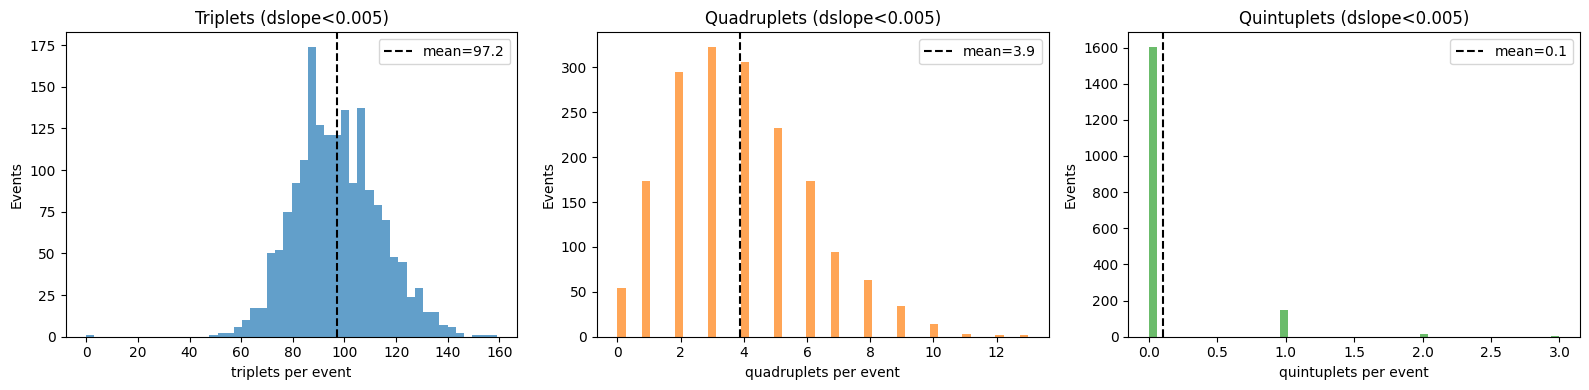

In [33]:
# Chain multiplicity distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, (col, color) in enumerate(zip(["triplets", "quadruplets", "quintuplets"], ["C0", "C1", "C2"])):
    data = chain_stats_df[col]
    axes[i].hist(data, bins=50, color=color, alpha=0.7)
    axes[i].axvline(data.mean(), color="k", ls="--", label=f"mean={data.mean():.1f}")
    axes[i].set_xlabel(f"{col} per event")
    axes[i].set_ylabel("Events")
    axes[i].set_title(f"{col.capitalize()} (dslope<{DSLOPE_MAX})")
    axes[i].legend()

fig.tight_layout()
plt.show()

Event 9:
  Triplets:    95
  Quadruplets: 4
  Quintuplets: 1


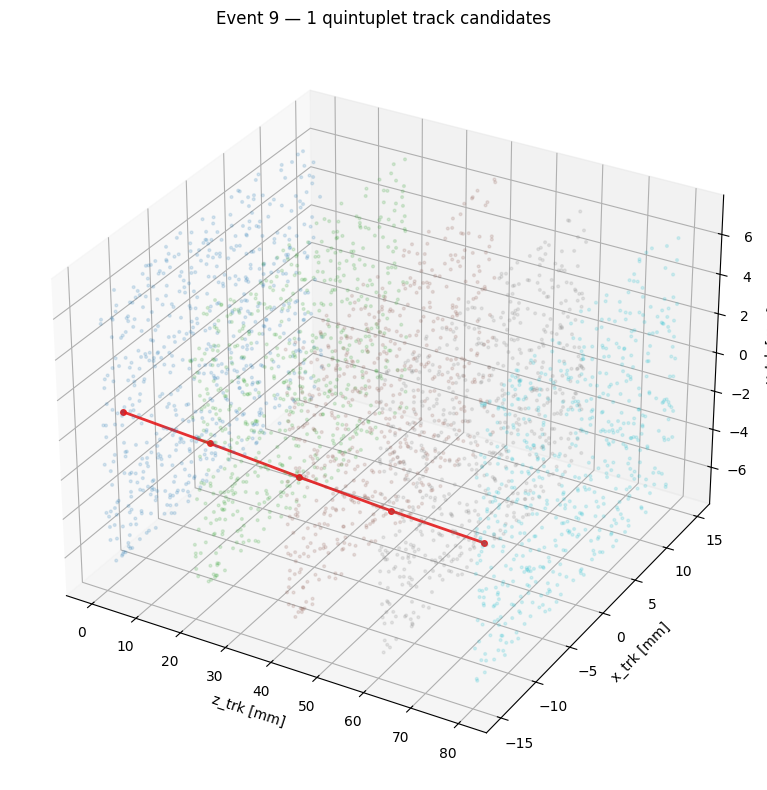

In [35]:
# Find an event with quintuplets and visualize
events_with_quint = chain_stats_df[chain_stats_df["quintuplets"] > 0].index
# Map index back to event_id
event_ids = df["event_id"].unique()
viz_event = event_ids[events_with_quint[0]] if len(events_with_quint) > 0 else example_event

evt_edges_single = edges_compressed[edges_compressed["event_id"] == viz_event]
chains_single = build_chains_for_event(evt_edges_single, dslope_x_max=DSLOPE_MAX, dslope_y_max=DSLOPE_MAX)

print(f"Event {viz_event}:")
print(f"  Triplets:    {len(chains_single['triplets'])}")
print(f"  Quadruplets: {len(chains_single['quadruplets'])}")
print(f"  Quintuplets: {len(chains_single['quintuplets'])}")

# 3D visualization: all hits + quintuplets as track candidates
evt_nodes = df.loc[df["event_id"] == viz_event]
node_coords = evt_nodes[["x_trk_mm", "y_trk_mm", "z_trk_mm"]]

fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(111, projection="3d")

# Draw all hits (faded)
colors_layer = plt.cm.tab10(np.linspace(0, 1, 5))
for lid in range(5):
    sub = evt_nodes[evt_nodes["layer_id"] == lid]
    ax.scatter(sub["z_trk_mm"], sub["x_trk_mm"], sub["y_trk_mm"],
               s=4, alpha=0.15, color=colors_layer[lid])

# Draw quintuplets as bold colored lines
quints = chains_single["quintuplets"]
if len(quints) == 0:
    quints = chains_single["quadruplets"][:10]  # fallback to quadruplets
    chain_label = "quadruplet"
else:
    chain_label = "quintuplet"

chain_colors = plt.cm.Set1(np.linspace(0, 1, max(len(quints), 1)))
for i, chain in enumerate(quints):
    nodes = chain["nodes"]
    xs, ys, zs = [], [], []
    for n in nodes:
        c = node_coords.loc[n]
        xs.append(c["x_trk_mm"])
        ys.append(c["y_trk_mm"])
        zs.append(c["z_trk_mm"])
    ax.plot(zs, xs, ys, color=chain_colors[i % len(chain_colors)],
            lw=2.0, alpha=0.9, marker="o", markersize=4)

ax.set_xlabel("z_trk [mm]")
ax.set_ylabel("x_trk [mm]")
ax.set_zlabel("y_trk [mm]")
ax.set_title(f"Event {viz_event} — {len(quints)} {chain_label} track candidates")
fig.tight_layout()
plt.show()

In [36]:
# Summary: compression pipeline overview
print("=" * 60)
print("COMPRESSION PIPELINE SUMMARY")
print("=" * 60)
print(f"{'Stage':<35} {'Mean/event':>12} {'Ratio':>8}")
print("-" * 60)
print(f"{'Raw edges (±3 mm window)':<35} {stats_old.mean():>12.0f} {'1x':>8}")
print(f"{'Slope<0.02 + KNN k=10':<35} {stats_new.mean():>12.0f} {stats_old.mean()/stats_new.mean():>7.1f}x")
print(f"{'Triplets (dslope<{DSLOPE_MAX})':<35} {chain_stats_df['triplets'].mean():>12.1f} {'':>8}")
print(f"{'Quadruplets':<35} {chain_stats_df['quadruplets'].mean():>12.1f} {'':>8}")
print(f"{'Quintuplets (track candidates)':<35} {chain_stats_df['quintuplets'].mean():>12.1f} {'':>8}")
print("=" * 60)
print(f"\nNodes per event: ~{len(evt_nodes)}")
print(f"Final track candidates per event: ~{chain_stats_df['quintuplets'].mean():.0f}")

COMPRESSION PIPELINE SUMMARY
Stage                                 Mean/event    Ratio
------------------------------------------------------------
Raw edges (±3 mm window)                  113203       1x
Slope<0.02 + KNN k=10                       2346    48.2x
Triplets (dslope<{DSLOPE_MAX})              97.2         
Quadruplets                                  3.9         
Quintuplets (track candidates)               0.1         

Nodes per event: ~3072
Final track candidates per event: ~0


## Track Fitting + Shared-Hit Rejection

In [12]:
def fit_line_3d(nodes: tuple, node_coords: pd.DataFrame) -> dict:
    """
    Fit x(z) = a_x * z + b_x  and  y(z) = a_y * z + b_y  to a chain of hits.
    Returns fit parameters, per-hit residuals, and chi2.
    """
    xs, ys, zs = [], [], []
    for n in nodes:
        c = node_coords.loc[n]
        xs.append(c["x_trk_mm"])
        ys.append(c["y_trk_mm"])
        zs.append(c["z_trk_mm"])
    
    xs = np.array(xs)
    ys = np.array(ys)
    zs = np.array(zs)
    n_pts = len(zs)
    
    # Linear fit: x = a_x * z + b_x
    A = np.column_stack([zs, np.ones(n_pts)])
    (a_x, b_x), res_x, _, _ = np.linalg.lstsq(A, xs, rcond=None)
    (a_y, b_y), res_y, _, _ = np.linalg.lstsq(A, ys, rcond=None)
    
    # Per-hit residuals
    x_fit = a_x * zs + b_x
    y_fit = a_y * zs + b_y
    dx = xs - x_fit
    dy = ys - y_fit
    dr = np.sqrt(dx**2 + dy**2)
    
    # Chi2-like metric (sum of squared residuals)
    chi2 = np.sum(dx**2 + dy**2)
    # Reduced chi2 (dof = n_pts - 2 parameters per coordinate = n_pts - 2,
    # but we have 2 coordinates so dof = 2*n_pts - 4)
    dof = max(2 * n_pts - 4, 1)
    chi2_red = chi2 / dof
    
    return {
        "nodes": nodes,
        "n_hits": n_pts,
        "a_x": a_x, "b_x": b_x,
        "a_y": a_y, "b_y": b_y,
        "residuals_x": dx,
        "residuals_y": dy,
        "residuals_r": dr,
        "max_residual": dr.max(),
        "mean_residual": dr.mean(),
        "chi2": chi2,
        "chi2_red": chi2_red,
    }


def fit_and_rank_candidates(
    chains: list[dict],
    node_coords: pd.DataFrame,
) -> pd.DataFrame:
    """Fit all chain candidates and return ranked DataFrame."""
    fits = []
    for chain in chains:
        f = fit_line_3d(chain["nodes"], node_coords)
        f["layers"] = chain["layers"]
        fits.append(f)
    
    if not fits:
        return pd.DataFrame()
    
    fit_df = pd.DataFrame(fits)
    fit_df = fit_df.sort_values("chi2_red").reset_index(drop=True)
    return fit_df


def shared_hit_rejection(fit_df: pd.DataFrame) -> pd.DataFrame:
    """
    Greedy shared-hit rejection:
    Iterate candidates sorted by chi2_red (best first).
    Accept a candidate only if none of its hits are already used.
    """
    if fit_df.empty:
        return fit_df
    
    used_nodes = set()
    accepted = []
    
    for _, row in fit_df.iterrows():
        nodes = set(row["nodes"])
        if nodes & used_nodes:
            continue  # has shared hits, reject
        accepted.append(row)
        used_nodes |= nodes
    
    if not accepted:
        return pd.DataFrame()
    return pd.DataFrame(accepted).reset_index(drop=True)

print("Fit + rejection functions defined.")

Fit + rejection functions defined.


In [13]:
# Quintuplets are rare (~0.1/event). Use a slightly looser dslope to get
# more candidates, then let chi2 fitting do the quality selection.
DSLOPE_FIT = 0.008  # looser than 0.005

# Collect all quintuplet + quadruplet candidates per event, fit, and reject
all_accepted_tracks = []
all_fit_stats = {"event_id": [], "n_quint_raw": [], "n_quad_raw": [],
                 "n_quint_accepted": [], "n_quad_accepted": [], "n_total_accepted": []}

for event_id, evt_edges in edges_compressed.groupby("event_id", sort=True):
    chains = build_chains_for_event(evt_edges, dslope_x_max=DSLOPE_FIT, dslope_y_max=DSLOPE_FIT)
    
    evt_nodes = df.loc[df["event_id"] == event_id]
    node_coords = evt_nodes[["x_trk_mm", "y_trk_mm", "z_trk_mm"]]
    
    # Combine quintuplets (priority) and quadruplets
    all_candidates = chains["quintuplets"] + chains["quadruplets"]
    
    if len(all_candidates) == 0:
        all_fit_stats["event_id"].append(event_id)
        all_fit_stats["n_quint_raw"].append(len(chains["quintuplets"]))
        all_fit_stats["n_quad_raw"].append(len(chains["quadruplets"]))
        all_fit_stats["n_quint_accepted"].append(0)
        all_fit_stats["n_quad_accepted"].append(0)
        all_fit_stats["n_total_accepted"].append(0)
        continue
    
    fit_df = fit_and_rank_candidates(all_candidates, node_coords)
    accepted = shared_hit_rejection(fit_df)
    
    for _, trk in accepted.iterrows():
        all_accepted_tracks.append({
            "event_id": event_id,
            "nodes": trk["nodes"],
            "layers": trk["layers"],
            "n_hits": trk["n_hits"],
            "chi2_red": trk["chi2_red"],
            "mean_residual": trk["mean_residual"],
            "max_residual": trk["max_residual"],
            "a_x": trk["a_x"],
            "b_x": trk["b_x"],
            "a_y": trk["a_y"],
            "b_y": trk["b_y"],
        })
    
    n_q5_acc = sum(1 for _, t in accepted.iterrows() if t["n_hits"] == 5)
    n_q4_acc = sum(1 for _, t in accepted.iterrows() if t["n_hits"] == 4)
    
    all_fit_stats["event_id"].append(event_id)
    all_fit_stats["n_quint_raw"].append(len(chains["quintuplets"]))
    all_fit_stats["n_quad_raw"].append(len(chains["quadruplets"]))
    all_fit_stats["n_quint_accepted"].append(n_q5_acc)
    all_fit_stats["n_quad_accepted"].append(n_q4_acc)
    all_fit_stats["n_total_accepted"].append(len(accepted))

tracks_df = pd.DataFrame(all_accepted_tracks)
fit_stats_df = pd.DataFrame(all_fit_stats)

print(f"=== Track Finding Results (dslope_fit = {DSLOPE_FIT}) ===")
print(f"Total accepted tracks: {len(tracks_df)}")
print(f"\nAccepted tracks per event:")
print(fit_stats_df["n_total_accepted"].describe())
print(f"\nBy type:")
print(f"  5-hit tracks: {fit_stats_df['n_quint_accepted'].sum()}")
print(f"  4-hit tracks: {fit_stats_df['n_quad_accepted'].sum()}")

=== Track Finding Results (dslope_fit = 0.008) ===
Total accepted tracks: 28830

Accepted tracks per event:
count    1770.000000
mean       16.288136
std         4.446977
min         0.000000
25%        13.000000
50%        16.000000
75%        19.000000
max        33.000000
Name: n_total_accepted, dtype: float64

By type:
  5-hit tracks: 121
  4-hit tracks: 28709


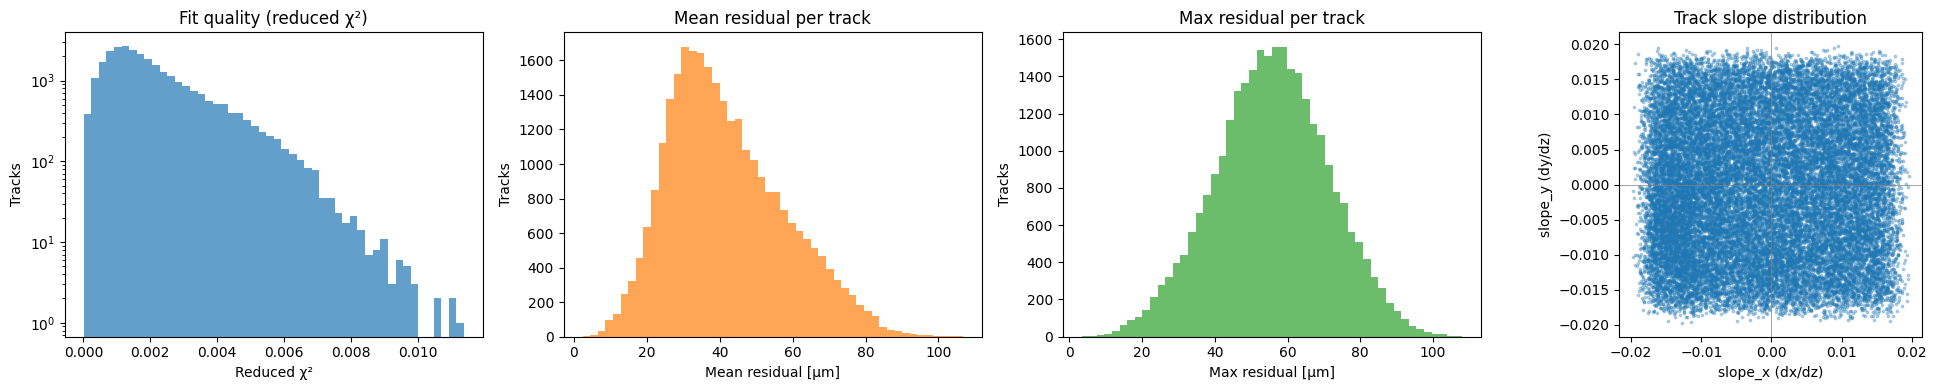

In [14]:
# Fit quality distributions
if len(tracks_df) > 0:
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    
    axes[0].hist(tracks_df["chi2_red"], bins=50, alpha=0.7, color="C0")
    axes[0].set_xlabel("Reduced χ²")
    axes[0].set_ylabel("Tracks")
    axes[0].set_title("Fit quality (reduced χ²)")
    axes[0].set_yscale("log")
    
    axes[1].hist(tracks_df["mean_residual"] * 1e3, bins=50, alpha=0.7, color="C1")
    axes[1].set_xlabel("Mean residual [μm]")
    axes[1].set_ylabel("Tracks")
    axes[1].set_title("Mean residual per track")
    
    axes[2].hist(tracks_df["max_residual"] * 1e3, bins=50, alpha=0.7, color="C2")
    axes[2].set_xlabel("Max residual [μm]")
    axes[2].set_ylabel("Tracks")
    axes[2].set_title("Max residual per track")
    
    # Track slopes
    axes[3].scatter(tracks_df["a_x"], tracks_df["a_y"], s=3, alpha=0.3)
    axes[3].set_xlabel("slope_x (dx/dz)")
    axes[3].set_ylabel("slope_y (dy/dz)")
    axes[3].set_title("Track slope distribution")
    axes[3].set_aspect("equal")
    axes[3].axhline(0, color="gray", lw=0.5)
    axes[3].axvline(0, color="gray", lw=0.5)
    
    fig.tight_layout()
    plt.show()
else:
    print("No tracks found.")

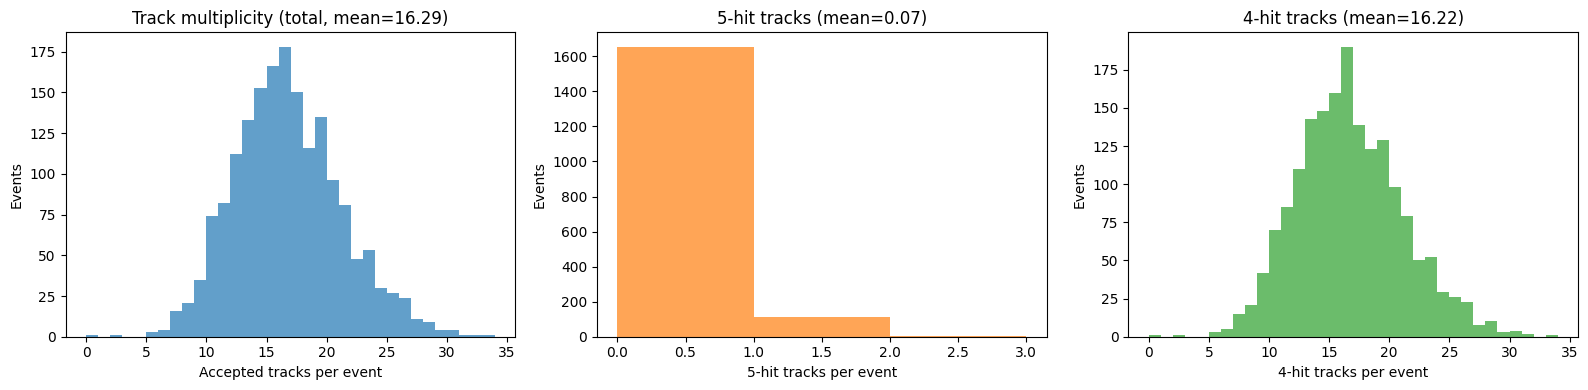

In [15]:
# Track multiplicity per event
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(fit_stats_df["n_total_accepted"], bins=range(0, fit_stats_df["n_total_accepted"].max()+2),
             alpha=0.7, color="C0")
axes[0].set_xlabel("Accepted tracks per event")
axes[0].set_ylabel("Events")
axes[0].set_title(f"Track multiplicity (total, mean={fit_stats_df['n_total_accepted'].mean():.2f})")

axes[1].hist(fit_stats_df["n_quint_accepted"], bins=range(0, max(fit_stats_df["n_quint_accepted"].max()+2, 3)),
             alpha=0.7, color="C1")
axes[1].set_xlabel("5-hit tracks per event")
axes[1].set_ylabel("Events")
axes[1].set_title(f"5-hit tracks (mean={fit_stats_df['n_quint_accepted'].mean():.2f})")

axes[2].hist(fit_stats_df["n_quad_accepted"], bins=range(0, max(fit_stats_df["n_quad_accepted"].max()+2, 3)),
             alpha=0.7, color="C2")
axes[2].set_xlabel("4-hit tracks per event")
axes[2].set_ylabel("Events")
axes[2].set_title(f"4-hit tracks (mean={fit_stats_df['n_quad_accepted'].mean():.2f})")

fig.tight_layout()
plt.show()

Event 14: 17 accepted tracks (1 quintuplets, 16 quadruplets)
  Track 0: 4 hits, χ²/dof=0.0004, mean_res=17.9 μm, max_res=32.9 μm, slope=(0.00111, 0.01191)
  Track 1: 4 hits, χ²/dof=0.0007, mean_res=23.3 μm, max_res=39.2 μm, slope=(-0.00276, 0.01682)
  Track 2: 5 hits, χ²/dof=0.0008, mean_res=29.5 μm, max_res=39.8 μm, slope=(0.00055, -0.01485)
  Track 3: 4 hits, χ²/dof=0.0011, mean_res=29.9 μm, max_res=50.1 μm, slope=(-0.01741, 0.00064)
  Track 4: 4 hits, χ²/dof=0.0015, mean_res=37.3 μm, max_res=46.9 μm, slope=(-0.01131, -0.00192)
  Track 5: 4 hits, χ²/dof=0.0016, mean_res=38.4 μm, max_res=53.4 μm, slope=(0.01067, 0.00172)
  Track 6: 4 hits, χ²/dof=0.0017, mean_res=41.7 μm, max_res=46.1 μm, slope=(0.01175, -0.00697)
  Track 7: 4 hits, χ²/dof=0.0020, mean_res=44.1 μm, max_res=56.8 μm, slope=(-0.01374, 0.01151)
  Track 8: 4 hits, χ²/dof=0.0020, mean_res=43.5 μm, max_res=62.1 μm, slope=(-0.00598, -0.00140)
  Track 9: 4 hits, χ²/dof=0.0022, mean_res=45.7 μm, max_res=60.0 μm, slope=(-0.01018

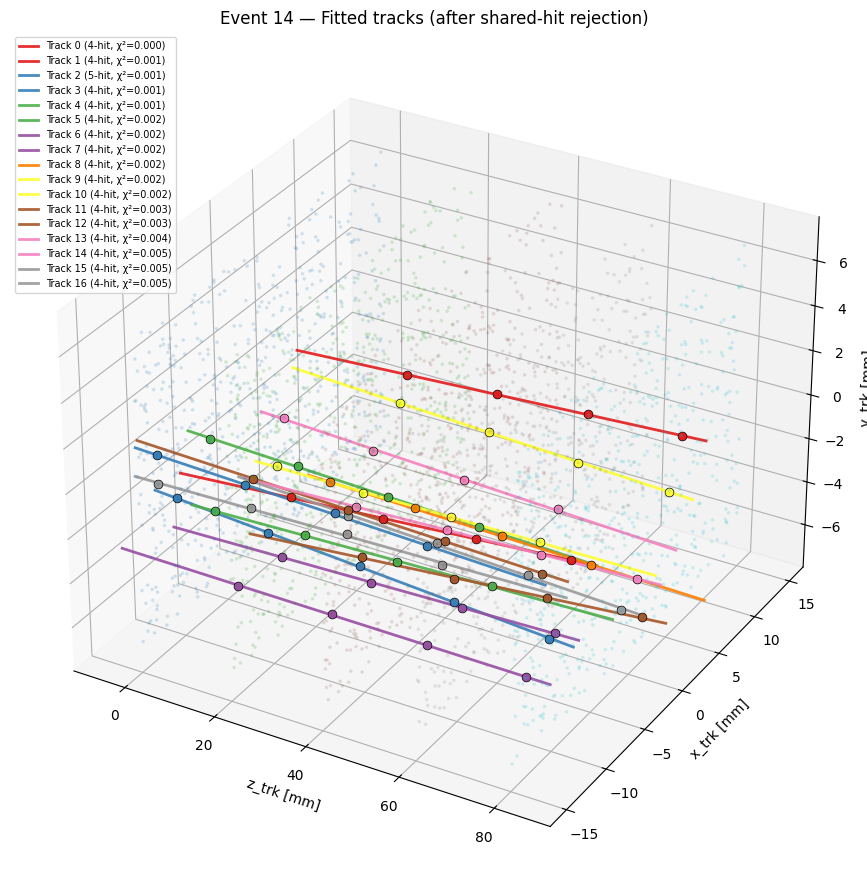

In [16]:
# Visualize fitted tracks for an event with tracks
events_with_tracks = fit_stats_df[fit_stats_df["n_total_accepted"] > 0]
# Prefer events with quintuplets
events_with_q5 = fit_stats_df[fit_stats_df["n_quint_accepted"] > 0]
if len(events_with_q5) > 0:
    viz_eid = events_with_q5.iloc[0]["event_id"]
else:
    viz_eid = events_with_tracks.iloc[0]["event_id"]

viz_tracks = tracks_df[tracks_df["event_id"] == viz_eid]
viz_nodes = df.loc[df["event_id"] == viz_eid]
viz_coords = viz_nodes[["x_trk_mm", "y_trk_mm", "z_trk_mm"]]

print(f"Event {int(viz_eid)}: {len(viz_tracks)} accepted tracks ({(viz_tracks['n_hits']==5).sum()} quintuplets, {(viz_tracks['n_hits']==4).sum()} quadruplets)")
for i, (_, trk) in enumerate(viz_tracks.iterrows()):
    print(f"  Track {i}: {trk['n_hits']} hits, χ²/dof={trk['chi2_red']:.4f}, "
          f"mean_res={trk['mean_residual']*1e3:.1f} μm, max_res={trk['max_residual']*1e3:.1f} μm, "
          f"slope=({trk['a_x']:.5f}, {trk['a_y']:.5f})")

# 3D plot
fig = plt.figure(figsize=(14, 9))
ax = fig.add_subplot(111, projection="3d")

colors_layer = plt.cm.tab10(np.linspace(0, 1, 5))
for lid in range(5):
    sub = viz_nodes[viz_nodes["layer_id"] == lid]
    ax.scatter(sub["z_trk_mm"], sub["x_trk_mm"], sub["y_trk_mm"],
               s=3, alpha=0.12, color=colors_layer[lid])

# Draw fitted tracks as lines spanning z range
z_plot = np.linspace(-5, 85, 100)
track_colors = plt.cm.Set1(np.linspace(0, 1, max(len(viz_tracks), 1)))

for i, (_, trk) in enumerate(viz_tracks.iterrows()):
    # Draw fit line
    x_fit = trk["a_x"] * z_plot + trk["b_x"]
    y_fit = trk["a_y"] * z_plot + trk["b_y"]
    n_label = int(trk["n_hits"])
    ax.plot(z_plot, x_fit, y_fit, color=track_colors[i], lw=2.0, alpha=0.9,
            label=f"Track {i} ({n_label}-hit, χ²={trk['chi2_red']:.3f})")
    
    # Mark actual hits
    for n in trk["nodes"]:
        c = viz_coords.loc[n]
        ax.scatter([c["z_trk_mm"]], [c["x_trk_mm"]], [c["y_trk_mm"]],
                   s=40, color=track_colors[i], edgecolors="k", linewidth=0.5, zorder=5)

ax.set_xlabel("z_trk [mm]")
ax.set_ylabel("x_trk [mm]")
ax.set_zlabel("y_trk [mm]")
ax.set_title(f"Event {int(viz_eid)} — Fitted tracks (after shared-hit rejection)")
ax.legend(fontsize=7, loc="upper left")
fig.tight_layout()
plt.show()

In [17]:
# Final summary
print("=" * 65)
print("TRADITIONAL SEEDING + FITTING BASELINE SUMMARY")
print("=" * 65)
print(f"{'Parameter':<40} {'Value':>20}")
print("-" * 65)
print(f"{'Slope window (edge building)':<40} {'±0.02':>20}")
print(f"{'KNN k (edge pruning)':<40} {'10':>20}")
print(f"{'Δslope (chain building)':<40} {f'±{DSLOPE_FIT}':>20}")
print(f"{'Fit model':<40} {'Linear x(z), y(z)':>20}")
print(f"{'Rejection strategy':<40} {'Greedy, χ²-ranked':>20}")
print("-" * 65)
print(f"{'Total events':<40} {len(fit_stats_df):>20}")
print(f"{'Events with ≥1 track':<40} {(fit_stats_df['n_total_accepted']>0).sum():>20}")
print(f"{'Total accepted tracks':<40} {len(tracks_df):>20}")
print(f"{'  5-hit tracks':<40} {(tracks_df['n_hits']==5).sum() if len(tracks_df)>0 else 0:>20}")
print(f"{'  4-hit tracks':<40} {(tracks_df['n_hits']==4).sum() if len(tracks_df)>0 else 0:>20}")
print(f"{'Mean tracks / event':<40} {fit_stats_df['n_total_accepted'].mean():>20.2f}")
if len(tracks_df) > 0:
    print(f"{'Mean reduced χ²':<40} {tracks_df['chi2_red'].mean():>20.4f}")
    print(f"{'Median mean residual [μm]':<40} {tracks_df['mean_residual'].median()*1e3:>20.1f}")
    print(f"{'Median max residual [μm]':<40} {tracks_df['max_residual'].median()*1e3:>20.1f}")
print("=" * 65)

TRADITIONAL SEEDING + FITTING BASELINE SUMMARY
Parameter                                               Value
-----------------------------------------------------------------
Slope window (edge building)                            ±0.02
KNN k (edge pruning)                                       10
Δslope (chain building)                                ±0.008
Fit model                                   Linear x(z), y(z)
Rejection strategy                          Greedy, χ²-ranked
-----------------------------------------------------------------
Total events                                             1770
Events with ≥1 track                                     1769
Total accepted tracks                                   28830
  5-hit tracks                                            121
  4-hit tracks                                          28709
Mean tracks / event                                     16.29
Mean reduced χ²                                        0.0021
Median mean res